In [3]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [4]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [97]:
abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs))
end


function prepareGeneration(data) # does what BVH overload does, used for prototyping
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])

    return boxes,box

end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end



function recursiveSearch(point,leaf::BVHLeaf,bbox::Matrix) 
    return leaf.data 
end

function recursiveSearch(point,tree::BVHNode,bbox::Matrix)
    ax = tree.depth%3 + 1

    newBox = copy(bbox)

    line = (bbox[ax,2]+bbox[ax,1])/2
    if point[ax]<line
        newBox[ax,2] = line
        return recursiveSearch(point,tree.leftChild,newBox)
    end
    newBox[ax,1] = line
    return recursiveSearch(point,tree.rightChild,newBox)
end


@inline function intersection3D(p::SVector{3, Float64}, simplex::SMatrix{4, 3, Float64})
    @inbounds begin
        v1, v2, v3, v4 = simplex[1, :], simplex[2, :], simplex[3, :], simplex[4, :]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end

@inline function intersection3D(p::SVector{3, Float64}, simplex)
    @inbounds begin
        v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end

function intersection3D(p::Vector{Float64}, simplex::Matrix)
    sP = SVector{3}(p)
    sSimp = SMatrix{4,3}(simplex)
    return intersection3D(sP, sSimp)
end

function earlyStopSearch(p::Vector{Float64}, simplices::Vector)
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            return i
        end
    end
    return nothing
end

function earlyStopSearch(p::Vector{Float64}, simplices::Matrix)
    for (i, s) in pairs(eachrow(simplices))
        if intersection3D(p, s)
            return i
        end
    end
    return nothing
end


function findSimplex(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

    return simplNeighborhood[idx]
end

function findID(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

    return indices[idx]
end

function findID(point,simplices::Matrix, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices,:]

    idx = earlyStopSearch(point,simplNeighborhood)

    return indices[idx]
end




findID (generic function with 2 methods)

In [90]:
# get me some data
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]

# tesselation + Triangulation3D
coords, tets = TesselationCore.tesselate(points3d)
tes = TesselationCore.Triangulation3D(points3d,tets')

#TODO do this smarter later
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])

bvh = BVH(simplices,9)



Manual WeightsSVector{3, Float64}[[0.44516410129470574, 0.8871537209997226, 0.620307168165609], [0.3337471623343896, 0.45936843759495094, 0.6844089001129248], [0.44516410129470574, 0.8871537209997226, 0.620307168165609], [0.047078776775217324, 0.8564723998568702, 0.9361031147134479], [0.017976723058831134, 0.3629327431991778, 0.4637516510628473], [0.047078776775217324, 0.8564723998568702, 0.9361031147134479], [0.38974019831211415, 0.7465691902476168, 0.36889595638394024], [0.9328264936470599, 0.8667274023833598, 0.17020270700297968], [0.26293669470542647, 0.27296847288387216, 0.4412704898227393], [0.017976723058831134, 0.3629327431991778, 0.4637516510628473], [0.04145279496611798, 0.16539773745080233, 0.15788943498501162], [0.45773493060173076, 0.3504961957043109, 0.0965483150604044], [0.45773493060173076, 0.3504961957043109, 0.0965483150604044], [0.13818740362572512, 0.4398944162082148, 0.38389245796069815], [0.24738064240894364, 0.9242675031034165, 0.18674044189611017], [0.3712998622

BVH(BVHNode(9, BVHNode(8, BVHNode(7, BVHNode(6, BVHNode(5, BVHNode(4, BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([110, 134]), BVHLeaf([9, 13, 110, 134, 192])), BVHNode(1, BVHLeaf([110, 114, 115, 134, 135, 145, 177]), BVHLeaf([9, 10, 11, 13, 53, 66, 110, 114, 115, 134, 135, 145, 177, 192]))), BVHNode(2, BVHNode(1, BVHLeaf([110, 134]), BVHLeaf([9, 13, 110, 134, 192])), BVHNode(1, BVHLeaf([110, 114, 115, 134, 135, 145, 177]), BVHLeaf([9, 10, 11, 13, 53, 66, 110, 114, 115, 134, 135, 145, 177, 192])))), BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([9, 13, 18, 35, 110, 134, 192]), BVHLeaf([9, 13, 18, 35, 192])), BVHNode(1, BVHLeaf([9, 10, 11, 13, 18, 20, 35, 53, 61, 66, 110, 114, 115, 134, 135, 192]), BVHLeaf([9, 10, 11, 13, 14, 18, 20, 35, 40, 41, 53, 60, 61, 66, 115, 192]))), BVHNode(2, BVHNode(1, BVHLeaf([9, 12, 13, 18, 35, 36, 110, 127, 134, 192]), BVHLeaf([9, 12, 13, 18, 35, 36, 127, 192])), BVHNode(1, BVHLeaf([9, 10, 11, 12, 13, 18, 20, 35, 36, 53, 61, 66, 110, 114, 115, 127, 134, 135, 192])

In [7]:
function plotPlex!(simp,col = :black)
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=col,label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=col,label="")
    end
end

plotPlex! (generic function with 2 methods)

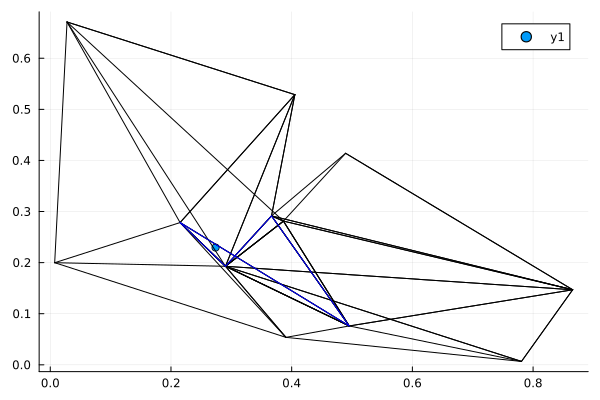

In [28]:

point = rand(3)


indices = recursiveSearch(point,bvh.tree,bvh.bbox)

simplNeighborhood = simplices[indices]


plot = Plots.scatter([point[1]],[point[2]])

for plex in simplNeighborhood
    plotPlex!(plex)
end


ind = earlyStopSearch(point,simplNeighborhood)
final = simplNeighborhood[ind]

plotPlex!(final,:blue)

plot


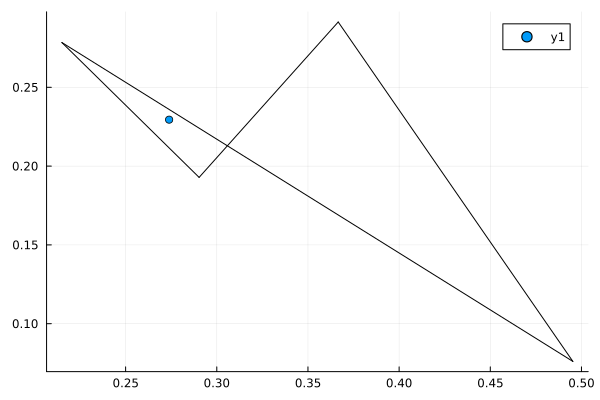

In [30]:
idx = findID(point,simplices, bvh::BVH) 
plex = simplices[idx]


plot = Plots.scatter([point[1]],[point[2]])
plotPlex!(plex)
plot

In [32]:

tet = tets[idx,:]
simp = tes.points[tet]
rhos = tes.ρStar[tet]


4-element Vector{Float64}:
 6304.69905867257
 4974.468355492837
 3690.6490737500385
 5405.191450821026

In [33]:
function invertCramer(rhos,simplex)
    r = rhos[2:end] .- rhos[1]  

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    detA = dot(a, cross(b, c))
    x1 = dot(r, cross(b, c)) / detA
    x2 = dot(r, cross(c, a)) / detA
    x3 = dot(r, cross(a, b)) / detA

    return [x1,x2,x3]

end


function invertClassic(rhos,simplex) 
    r = rhos[2:end] .- rhos[1]

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    mat = SMatrix{3,3}([a;b;c])
    
    return inv(mat)*r
end


invertClassic (generic function with 1 method)

In [34]:
x1 = invertClassic(rhos,simp)
x2 = invertCramer(rhos,simp)

3-element Vector{Float64}:
 -27602.392823117963
   6204.032146643991
  12884.448286914141

In [35]:
x2-x1

3-element SVector{3, Float64} with indices SOneTo(3):
 -3.637978807091713e-12
  0.0
  1.8189894035458565e-12

In [37]:
point = rand(3)
idx = findID(point,simplices, bvh::BVH) 

tet = tets[idx,:]
simp = tes.points[tet]
rhos = tes.ρStar[tet]

4-element Vector{Float64}:
 5960.81250323425
 8496.375952508677
 4383.353787672216
 1109.9581539325586

In [38]:
@btime invertClassic(rhos,simp)
@btime invertCramer(rhos,simp)

  160.666 ns (5 allocations: 192 bytes)
  165.182 ns (6 allocations: 240 bytes)


3-element Vector{Float64}:
 -11554.50304833481
   3514.7720347341447
  11560.91839288707

In [39]:
delRho = invertClassic(rhos,simp)

3-element SVector{3, Float64} with indices SOneTo(3):
 -11554.50304833481
   3514.772034734146
  11560.918392887066

In [40]:
interpolation = rhos[1] + dot((point - simp[1]),delRho)

4828.264726231879

In [42]:
rhos

4-element Vector{Float64}:
 5960.81250323425
 8496.375952508677
 4383.353787672216
 1109.9581539325586

In [44]:
function linearInterpolation(point, tet, triangulation) #TODO
    pts= triangulation.points[tet]
    ρs = triangulation.ρStar[tet]
    
    return ρs[1] + dot((point - simp[1]),invertClassic(ρs, pts)) 
end

linearInterpolation (generic function with 1 method)

In [45]:
linearInterpolation(point,tet,tes)

4828.264726231879

In [56]:
function standardEstimator(points, weights)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets',weights)

#TODO do this smarter later
    simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])

    bvh = BVH(simplices,9)

    return bvh,tes,tets
end


function DTFE(point,bvh,tetrahedra,tesselation)

    coords = tesselation.points
    simplices = coords[tets]

    i = findID(point,simplices,bvh)
    
    final = simplNeighborhood[i]

    tet = tets[i,:]
    simp = tes.points[tet]
    rhos = tes.ρStar[tet]

    delRho=invertClassic(rhos,simp)

    interpolation = rhos[1] + dot((point - simp[1]),delRho)

    return interpolation
end

DTFE (generic function with 1 method)

In [58]:
coords = tes.points
simplices = coords[tets]

216×4 Matrix{SVector{3, Float64}}:
 [0.390439, 0.0537155, 0.561906]   …  [0.780732, 0.00662101, 0.462907]
 [0.00732187, 0.199841, 0.619554]     [0.0345557, 0.121829, 0.973027]
 [0.495282, 0.0760421, 0.431135]      [0.390439, 0.0537155, 0.561906]
 [0.26367, 0.789044, 0.155038]        [0.168592, 0.821161, 0.177989]
 [0.386333, 0.281235, 0.00199171]     [0.405263, 0.528727, 0.368197]
 [0.2903, 0.192845, 0.100367]      …  [0.780732, 0.00662101, 0.462907]
 [0.386333, 0.281235, 0.00199171]     [0.2903, 0.192845, 0.100367]
 [0.366596, 0.291468, 0.411821]       [0.405263, 0.528727, 0.368197]
 [0.366596, 0.291468, 0.411821]       [0.582837, 0.135813, 0.607333]
 [0.495282, 0.0760421, 0.431135]      [0.215056, 0.278424, 0.479214]
 ⋮                                 ⋱  
 [0.94941, 0.181591, 0.668683]        [0.802603, 0.190064, 0.489376]
 [0.74872, 0.610019, 0.11786]         [0.865565, 0.146887, 0.315251]
 [0.386333, 0.281235, 0.00199171]     [0.865565, 0.146887, 0.315251]
 [0.951039, 0.591465, 0.4

In [92]:
typeof(simplices[1,:])

Vector{Adjoint{Float64, Matrix{Float64}}} (alias for Array{Adjoint{Float64, Array{Float64, 2}}, 1})

In [98]:
intersection3D(point,simplices[1,:])

DimensionMismatch: DimensionMismatch: expected input array of length 12, got length 1

In [84]:
idx = earlyStopSearch(point,simplNeighborhood)


DimensionMismatch: DimensionMismatch: expected input array of length 12, got length 4

In [76]:
findID(point,simplices,bvh)

DimensionMismatch: DimensionMismatch: expected input array of length 12, got length 4

In [65]:
typeof(simplNeighborhood)

Vector{SVector{3, Float64}} (alias for Array{SArray{Tuple{3}, Float64, 1, 3}, 1})

In [69]:
simplNeighborhood[1]

3-element SVector{3, Float64} with indices SOneTo(3):
 0.2636702369743674
 0.7890437595759543
 0.1550377069339648

In [ ]:
intersection3D(point,simplNeighborhood[1])

#idx = earlyStopSearch(point,simplNeighborhood)


DimensionMismatch: DimensionMismatch: No precise constructor for SMatrix{4, 3} found. Size of input was (3,).

In [57]:
DTFE(point,bvh,tets,tes)

DimensionMismatch: DimensionMismatch: No precise constructor for SMatrix{4, 3} found. Size of input was (3,).